In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from idlpy import *
import cartopy.crs as ccrs
import cartopy.feature as cf
import datetime

IDL 8.7.2 (linux x86_64 m64).
(c) 2019, Harris Geospatial Solutions, Inc.

Licensed for use by: NIWA - National Institute of Water and Atmospheric Research Ltd - Ashley
License: 397292


In [2]:
'''
Create vegetation land mask
'''

vege_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/vegetation/1951-2021.nc')
vege_ds['longitude'] = [lon + 360 for lon in vege_ds.longitude.data]

d4pdf_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')

vege_ds = vege_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()
vege_ds = vege_ds.interp(longitude=d4pdf_da.longitude, latitude=d4pdf_da.latitude, method="linear")

full_lai = vege_ds.lai_hv + vege_ds.lai_lv
full_lai_max = full_lai.max('time')

vege_mask = full_lai_max.where(full_lai_max>3.5)


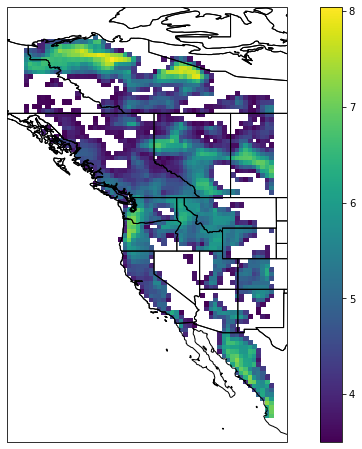

In [4]:
fig, axs = plt.subplots(1, 1, figsize=(12,8),subplot_kw=dict(projection=ccrs.PlateCarree()))

vege_mask.plot(ax=axs,transform=ccrs.PlateCarree())
axs.coastlines()  # cartopy function
axs.add_feature(cf.BORDERS)
axs.add_feature(cf.STATES)

plt.show()
plt.close(fig)

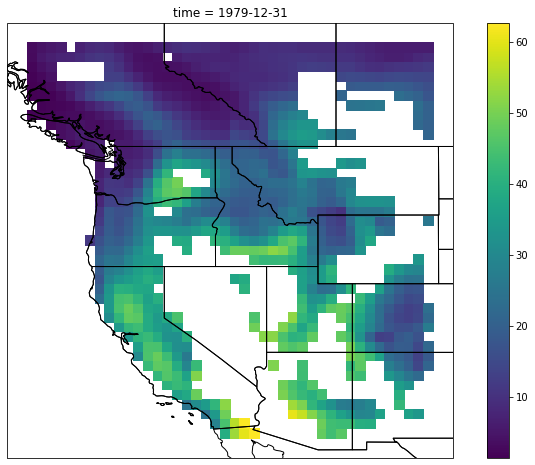

getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec


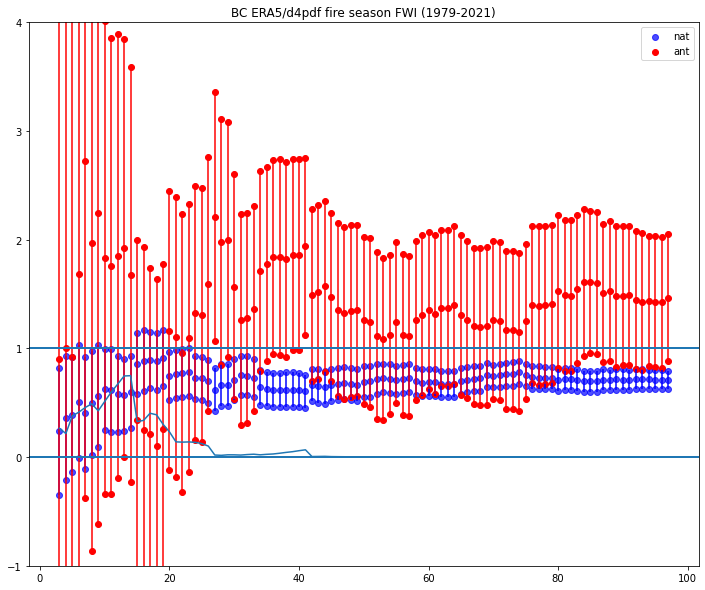

In [6]:
'''
MAIN function for performing optimal fingerprinting using d4pdf and ERA5
'''

#boxes = ['full',[(32,55),(232,256)]]#,[(32,55),(232,250)],[(32,55),(235,245)]]
boxes = [[(32,55),(232,256)]]

for vege_mask_flag in [True]:
    for box in boxes:

        #da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/d4pdf_resolution/ERA5_FWI_95p_d4pdf_resolution.nc')
        da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
        if box != 'full':
            da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        if vege_mask_flag:
            da = da.where(vege_mask>0)
        da = da.sel(time=slice("1979","2021"))
        
        fig, axs = plt.subplots(1, 1, figsize=(12,8),subplot_kw=dict(projection=ccrs.PlateCarree()))

        da.isel(time=0).plot(ax=axs,transform=ccrs.PlateCarree())
        axs.coastlines()  # cartopy function
        axs.add_feature(cf.BORDERS)
        axs.add_feature(cf.STATES)

        plt.show()
        plt.close(fig)


        IDL.retall

        print('getting ALL mean and noise')
        all_ens_mean,noise_all = get_mean_and_noise('HPB', box, vege_mask_flag)
        print('getting NAT mean and noise')
        nat_ens_mean,noise_nat = get_mean_and_noise('HPB_NAT', box, vege_mask_flag)

        print('getting obs')
        data_obs = get_obs_data(box, vege_mask_flag)
        print('got obs')
        data_scen = np.array([all_ens_mean,nat_ens_mean])
        #data_scen = np.array([ant_ens_mean,nat_ens_mean])

        data_noise_1 = np.concatenate((noise_all[:50],noise_nat[:50]))
        data_noise_2 = np.concatenate((noise_all[50:],noise_nat[50:]))

        print('got arrays')

        trunc = np.array([i for i in range(3,98)])

        IDL.data_obs = data_obs
        IDL.data_scen = data_scen
        IDL.data_noise_1 = data_noise_1
        IDL.data_noise_2 = data_noise_2
        IDL.trunc = trunc
        IDL.scan_beta_est = []
        IDL.scan_p_resid = []

        print('running gendetec')
        IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, scan_resid_sumsq=scan_resid_sumsq, \
                data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, scan_beta_est=scan_beta_est,\
                scan_p_resid=scan_p_resid")

        #IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, scan_resid_sumsq=scan_resid_sumsq, \
        #        data_noise_2=data_noise_2, trunc=trunc, scan_beta_est=scan_beta_est")

        scan_beta_est = IDL.scan_beta_est
        scan_p_resid = IDL.scan_p_resid

        plot_result(scan_beta_est,scan_p_resid)

        da.close()

In [3]:
def get_obs_data(box, vege_mask_flag):
         
    
    #d4pdf = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/95percentile/BC_wind_FWI/BC_wind_95_p_FWI_HPB_ensMean.nc')
    d4pdf = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')

    #da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/d4pdf_resolution/ERA5_FWI_95p_d4pdf_resolution.nc')
    da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
    if box != 'full':
        da = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

    if vege_mask_flag:
        da = da.where(vege_mask>0)
        
    da = da.sel(time=slice("1979","2021"))
    da = da.where(~d4pdf.isnull())
    
    da = da.stack(pixel=("latitude", "longitude"))
    da = da.dropna("pixel", how="all")        
    
    array = da.values.flatten()
    
    del da
    
    return(array)


In [4]:
def get_mean_and_noise(scen, box, vege_mask_flag):
    
    # 95th percentile
    #era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/95percentile/d4pdf_resolution/ERA5_FWI_95p_d4pdf_resolution.nc')
    # 6-month fire season
    era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
    
    # 95th percentile
    #ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/95percentile/BC_wind_FWI/BC_wind_95_p_FWI_'+scen+'_ensMean.nc')
    # 6-month fire season
    ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_'+scen+'_ensMean.nc')
    
    if box != 'full':
        ens_mean = ens_mean.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

    if vege_mask_flag:
        ens_mean = ens_mean.where(vege_mask>0)
        
    ens_mean = ens_mean.sel(time=slice("1979","2021"))
    ens_mean = ens_mean.where(~era5_da.isnull())
    
    noise = []
    for ens_mem in range(1,101):
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

        #mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/95percentile/BC_wind_FWI/BC_wind_95_p_FWI_'+scen+'_m'+number+'.nc')
        mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_'+scen+'_m'+number+'.nc')

        if box != 'full':
            mem_da = mem_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

        if vege_mask_flag:
            mem_da = mem_da.where(vege_mask>0)

        mem_da = mem_da.sel(time=slice("1979","2021"))
        mem_da = mem_da.where(~era5_da.isnull())

        diff = mem_da - ens_mean

        diff = diff.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
        diff = diff.dropna("pixel", how="all")# Drop the pixels that only have NA values.
                
        diff_array = diff.values.flatten()
        noise.append(diff_array)
        
        del mem_da
        del diff_array

    ens_mean = ens_mean.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
    ens_mean = ens_mean.dropna("pixel", how="all")# Drop the pixels that only have NA values.
    ens_mean_array = ens_mean.values.flatten()

    del ens_mean
    
    return((ens_mean_array, np.array(noise)))


In [5]:
def plot_result(scan_beta_est,scan_p_resid):

    fig,axs = plt.subplots(figsize=(12,10))

    for j in range(len(scan_beta_est)):

        beta_est = scan_beta_est[j]
        best_1,low_1,up_1 = beta_est[0][0],beta_est[1][0],beta_est[2][0]
        best_2,low_2,up_2 = beta_est[0][1],beta_est[1][1],beta_est[2][1]

        axs.scatter([j+3]*3,[low_2,best_2,up_2],c='blue',alpha=0.7,label='nat' if j == 0 else '')
        axs.scatter([j+3]*3,[low_1,best_1,up_1],c='red',label='ant' if j == 0 else '')

        axs.vlines(j+3,low_2,up_2,colors=['blue'])
        axs.vlines(j+3,low_1,up_1,colors=['red'])

        axs.axhline(0,-0.5,1.5)
        axs.axhline(1,-0.5,1.5)

    axs.plot([i+3 for i in range(len(scan_p_resid))],scan_p_resid)

    axs.legend()
    axs.set_ylim(-1,4)

    plt.title('BC ERA5/d4pdf fire season FWI (1979-2021)')
    #plt.savefig('/nesi/project/niwa00015/queenle/plots/fire/era5_fingerprinting/FWI/6month_fire_season/'+resample_interval+'/result.png')
    plt.show()
    #plt.close(fig)
    

In [ ]:
'''
calculate 6 month fire season, coarsen + interpolate ERA5 FWI to model grid

Save file '/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/FWI_6month_fire_season_model_grid.nc'
'''

'''
def fire_season(month):
    return (month >= 5) & (month <= 10)    

# MEAN
d4pdf_da = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/FWI_HPB_ensMean.nc')

era5_da = xr.open_dataarray("/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/ERA5_FWI_1951-2021.nc")
months_selected = era5_da.sel(time=fire_season(era5_da['time.month']))
era5_da = months_selected.resample(time ='A').mean('time')
era5_da['longitude'] = [lon + 360 for lon in era5_da.longitude.data]

era5_da = era5_da.coarsen(latitude=3,longitude=3,boundary='pad').mean()
era5_da = era5_da.interp(longitude=d4pdf_da.longitude, latitude=d4pdf_da.latitude, method="linear")

era5_da = era5_da.where(~d4pdf_da.isnull())

era5_da.to_netcdf('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/FWI_6month_fire_season_model_grid.nc')

# INPUTS
d4pdf_da = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/FWI_HPB_ensMean.nc')

era5_inputs = xr.open_dataset("/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/inputs_1951-2021.nc")
months_selected = era5_inputs.sel(time=fire_season(era5_inputs['time.month']))
era5_inputs = months_selected.resample(time ='A').mean('time')
era5_inputs['longitude'] = [lon + 360 for lon in era5_inputs.longitude.data]

era5_inputs = era5_inputs.coarsen(latitude=3,longitude=3,boundary='pad').mean()
era5_inputs = era5_inputs.interp(longitude=d4pdf_da.longitude, latitude=d4pdf_da.latitude, method="linear")

era5_inputs = era5_inputs.where(~d4pdf_da.isnull())

era5_inputs.to_netcdf('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/FWI_inputs_6month_fire_season_model_grid.nc')
'''